# Loan Default Risk Prediction using Machine Learning and Explainable AI

**Dataset:** Home Credit Default Risk - `data/application_train.csv`  
**Target:** `TARGET`, where `0` means the loan was repaid and `1` means the customer defaulted.

This notebook is a complete end-to-end data science project suitable for a university assignment, GitHub portfolio, and data science showcase. It covers problem framing, data loading, cleaning, feature engineering, exploratory analysis, feature selection, model training, evaluation, explainable AI, business insights, and artifact export.

## 1. Problem Statement

### What is credit risk?
Credit risk is the possibility that a borrower will fail to meet repayment obligations. For a lender, this can mean missed installments, late payments, or complete default.

### Why loan default prediction is important
Loan default prediction helps lenders estimate risk before approving credit. Better prediction improves portfolio quality, pricing, capital planning, and responsible lending.

### Business impact of incorrect predictions
A **false negative** approves a risky customer as safe, which can create credit losses and collection costs. A **false positive** rejects or penalizes a safe customer, causing lost revenue and poor customer experience. Because default is rare but expensive, recall, precision, F1, and ROC AUC are more useful than accuracy alone.

### Objective
Build machine learning models that predict customer default and explain model decisions in business-friendly language using SHAP.

### Expected outcomes
The project will produce cleaned data, engineered features, professional visualizations, trained Logistic Regression, Random Forest, and XGBoost models, model comparison metrics, saved artifacts, SHAP explanations, and lending recommendations.

## 2. Data Loading

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBOOST_AVAILABLE = False
    print(f"XGBoost unavailable: {exc}")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_AVAILABLE = False
    print(f"SHAP unavailable: {exc}")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14

DATA_PATH = Path("data/application_train.csv")
OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
REPORTS_DIR = OUTPUT_DIR / "reports"
for directory in [OUTPUT_DIR, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = "TARGET"

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head(10))
display(df.tail(10))

Dataset shape: 307,511 rows x 122 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307501,456245,0,Cash loans,F,N,Y,3,81000.0,269550.0,11871.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307502,456246,0,Cash loans,F,N,Y,1,94500.0,225000.0,10620.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
307503,456247,0,Cash loans,F,N,Y,0,112500.0,345510.0,17770.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0
307504,456248,0,Cash loans,F,N,Y,0,153000.0,331920.0,16096.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307505,456249,0,Cash loans,F,N,Y,0,112500.0,225000.0,22050.0,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData type distribution:")
display(df.dtypes.value_counts().to_frame("count"))

print("\nDetailed data types:")
display(df.dtypes.to_frame("dtype"))

print("\nSummary statistics - numerical:")
display(df.describe().T)

print("\nSummary statistics - categorical:")
display(df.describe(include="object").T)

Column names:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONA

,count
float64,65
int64,41
str,16



Detailed data types:


,dtype
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,str
CODE_GENDER,str
FLAG_OWN_CAR,str
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64



Summary statistics - numerical:


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0



Summary statistics - categorical:


,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


,column,missing_percent
0,COMMONAREA_AVG,69.872297
1,COMMONAREA_MODE,69.872297
2,COMMONAREA_MEDI,69.872297
3,NONLIVINGAPARTMENTS_MEDI,69.432963
4,NONLIVINGAPARTMENTS_MODE,69.432963
5,NONLIVINGAPARTMENTS_AVG,69.432963
6,FONDKAPREMONT_MODE,68.386172
7,LIVINGAPARTMENTS_AVG,68.354953
8,LIVINGAPARTMENTS_MEDI,68.354953
9,LIVINGAPARTMENTS_MODE,68.354953


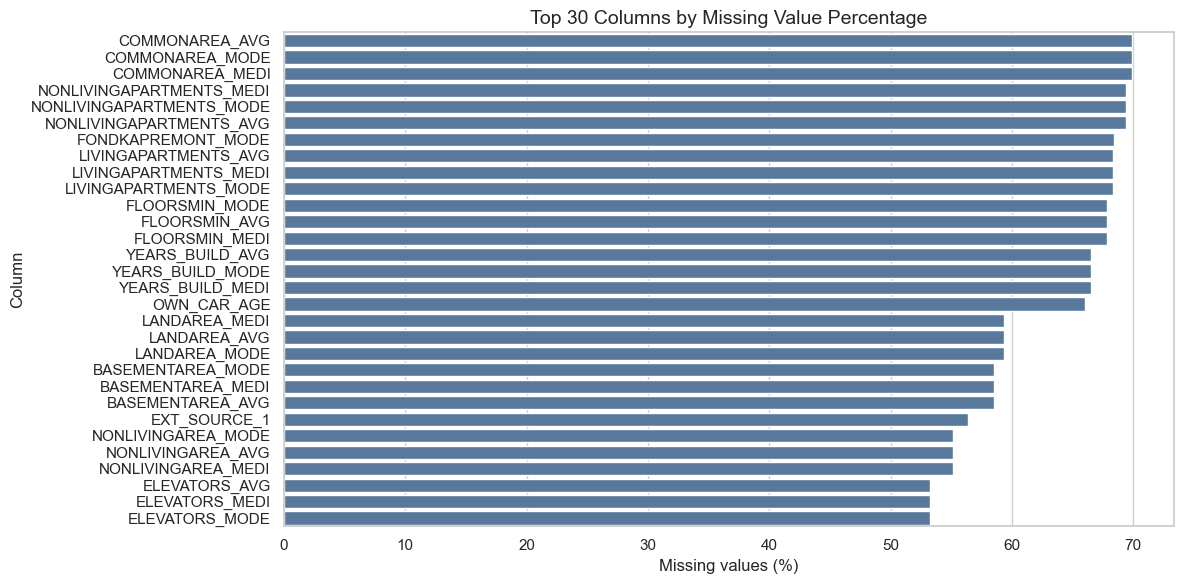

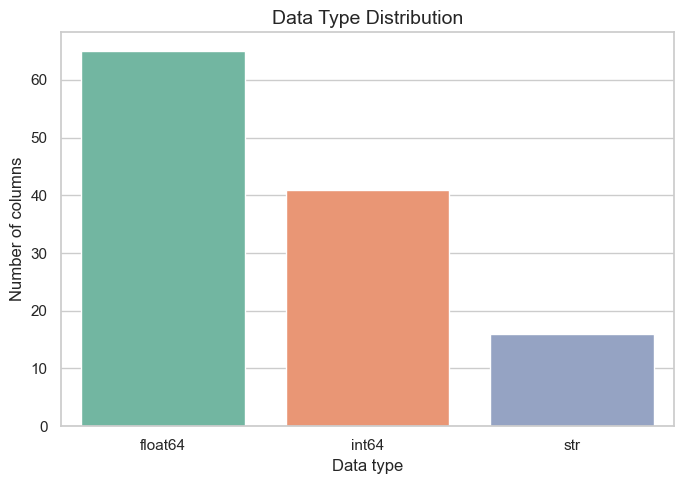

In [4]:
missing = (
    df.isna().mean().mul(100).sort_values(ascending=False)
    .rename("missing_percent").reset_index().rename(columns={"index": "column"})
)
display(missing.head(30))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=missing.head(30), x="missing_percent", y="column", color="#4C78A8", ax=ax)
ax.set_title("Top 30 Columns by Missing Value Percentage")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_value_percentages.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
dtype_counts = df.dtypes.astype(str).value_counts().reset_index()
dtype_counts.columns = ["dtype", "count"]
sns.barplot(data=dtype_counts, x="dtype", y="count", palette="Set2", ax=ax)
ax.set_title("Data Type Distribution")
ax.set_xlabel("Data type")
ax.set_ylabel("Number of columns")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "data_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Data Understanding

The dataset includes applicant demographics, income and loan amounts, employment history, external risk scores, housing information, social-circle risk indicators, and document flags. The target variable is imbalanced because most customers repay their loans.

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Numerical columns: {len(numerical_cols)}")
print(numerical_cols)
print(f"\nCategorical columns: {len(categorical_cols)}")
print(categorical_cols)
print(f"\nTarget variable: {TARGET}")

Numerical columns: 106
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEX

### Important Feature Explanations

- `AMT_INCOME_TOTAL`: Total declared customer income; indicates repayment capacity.
- `AMT_CREDIT`: Total loan amount; measures credit exposure.
- `AMT_ANNUITY`: Periodic loan payment; indicates repayment burden.
- `DAYS_BIRTH`: Customer age in days, stored as a negative value.
- `DAYS_EMPLOYED`: Employment duration in days; `365243` is a known placeholder and is treated as missing.
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`: External normalized risk scores that are often among the strongest predictors.

## 4. Data Cleaning

In [6]:
def clean_home_credit_data(data, target=TARGET, missing_threshold=0.60):
    cleaned = data.copy()
    log = []

    before_rows = len(cleaned)
    cleaned = cleaned.drop_duplicates()
    log.append(f"Removed {before_rows - len(cleaned):,} duplicate rows.")

    if "DAYS_EMPLOYED" in cleaned.columns:
        placeholder_count = (cleaned["DAYS_EMPLOYED"] == 365243).sum()
        cleaned["DAYS_EMPLOYED"] = cleaned["DAYS_EMPLOYED"].replace(365243, np.nan)
        log.append(f"Replaced {placeholder_count:,} DAYS_EMPLOYED placeholder values with missing values.")

    missing_pct = cleaned.isna().mean()
    high_missing_cols = [col for col in missing_pct[missing_pct > missing_threshold].index if col != target]
    cleaned = cleaned.drop(columns=high_missing_cols)
    log.append(f"Dropped {len(high_missing_cols)} columns with more than {missing_threshold:.0%} missing values.")

    numeric_features = [col for col in cleaned.select_dtypes(include=np.number).columns if col != target]
    categorical_features = cleaned.select_dtypes(include=["object", "category"]).columns.tolist()
    return cleaned, numeric_features, categorical_features, high_missing_cols, log

clean_df, numeric_features, categorical_features, dropped_missing_cols, cleaning_log = clean_home_credit_data(df)
for item in cleaning_log:
    print("-", item)
print(f"Cleaned shape before imputation/encoding: {clean_df.shape}")
print("Dropped columns:", dropped_missing_cols)

- Removed 0 duplicate rows.
- Replaced 55,374 DAYS_EMPLOYED placeholder values with missing values.
- Dropped 17 columns with more than 60% missing values.
Cleaned shape before imputation/encoding: (307511, 105)
Dropped columns: ['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']


In [7]:
def outlier_summary(data, columns):
    rows = []
    for col in columns:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({"feature": col, "lower_bound": lower, "upper_bound": upper, "outlier_count": count})
    return pd.DataFrame(rows).sort_values("outlier_count", ascending=False)

display(outlier_summary(clean_df, numeric_features).head(20))

def clip_outliers(data, columns, lower_q=0.01, upper_q=0.99):
    clipped = data.copy()
    bounds = {}
    for col in columns:
        lower = clipped[col].quantile(lower_q)
        upper = clipped[col].quantile(upper_q)
        clipped[col] = clipped[col].clip(lower, upper)
        bounds[col] = {"lower": None if pd.isna(lower) else float(lower), "upper": None if pd.isna(upper) else float(upper)}
    return clipped, bounds

clean_df, outlier_bounds = clip_outliers(clean_df, numeric_features)
print(f"Outlier handling complete: clipped {len(numeric_features)} numerical columns at the 1st and 99th percentiles.")
print("Missing values are imputed inside the model pipelines: numerical = median, categorical = most frequent.")

,feature,lower_bound,upper_bound,outlier_count
18,REGION_RATING_CLIENT,2.00000,2.00000,80527
19,REGION_RATING_CLIENT_W_CITY,2.00000,2.00000,78027
25,REG_CITY_NOT_WORK_CITY,0.00000,0.00000,70867
13,FLAG_WORK_PHONE,0.00000,0.00000,61308
12,FLAG_EMP_PHONE,1.00000,1.00000,55386
26,LIVE_CITY_NOT_WORK_CITY,0.00000,0.00000,55215
87,AMT_REQ_CREDIT_BUREAU_QRT,0.00000,0.00000,50575
86,AMT_REQ_CREDIT_BUREAU_MON,0.00000,0.00000,43759
59,DEF_30_CNT_SOCIAL_CIRCLE,0.00000,0.00000,35166
67,FLAG_DOCUMENT_6,0.00000,0.00000,27078


Outlier handling complete: clipped 89 numerical columns at the 1st and 99th percentiles.
Missing values are imputed inside the model pipelines: numerical = median, categorical = most frequent.


## 5. Feature Engineering

In [8]:
def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan) if isinstance(denominator, pd.Series) else denominator
    return numerator / denominator

def add_engineered_features(data):
    engineered = data.copy()
    engineered["CREDIT_INCOME_RATIO"] = safe_divide(engineered["AMT_CREDIT"], engineered["AMT_INCOME_TOTAL"])
    engineered["ANNUITY_INCOME_RATIO"] = safe_divide(engineered["AMT_ANNUITY"], engineered["AMT_INCOME_TOTAL"])
    engineered["EMPLOYMENT_AGE_RATIO"] = safe_divide(engineered["DAYS_EMPLOYED"], engineered["DAYS_BIRTH"])
    engineered["CREDIT_TERM"] = safe_divide(engineered["AMT_ANNUITY"], engineered["AMT_CREDIT"])
    engineered["CHILDREN_RATIO"] = safe_divide(engineered["CNT_CHILDREN"], engineered["CNT_FAM_MEMBERS"])
    return engineered.replace([np.inf, -np.inf], np.nan)

model_df = add_engineered_features(clean_df)
engineered_features = ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "EMPLOYMENT_AGE_RATIO", "CREDIT_TERM", "CHILDREN_RATIO"]
display(model_df[engineered_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.947609,2.641730,0.161714,2.026933,3.271525,5.142857,41.200000
ANNUITY_INCOME_RATIO,307499.0,0.180427,0.092331,0.013086,0.115385,0.162475,0.227800,1.555700
EMPLOYMENT_AGE_RATIO,252137.0,0.156157,0.131280,0.004664,0.056068,0.118663,0.219171,0.632822
CREDIT_TERM,307499.0,0.053538,0.022095,0.022073,0.037024,0.050000,0.063910,0.124430
CHILDREN_RATIO,307509.0,0.125338,0.199137,0.000000,0.000000,0.000000,0.333333,0.750000


### Business Meaning of Engineered Features

- `CREDIT_INCOME_RATIO`: Loan size relative to income; higher values can indicate heavier debt burden.
- `ANNUITY_INCOME_RATIO`: Payment pressure relative to income; higher values can signal affordability risk.
- `EMPLOYMENT_AGE_RATIO`: Employment stability relative to age.
- `CREDIT_TERM`: Annuity as a share of total credit, a repayment-structure proxy.
- `CHILDREN_RATIO`: Dependents relative to household size, which can affect disposable income.

## 6. Encoding

In [9]:
original_shape = model_df.shape
X_preview = model_df.drop(columns=[TARGET])
binary_cats = [col for col in categorical_features if col in X_preview.columns and X_preview[col].nunique(dropna=True) == 2]
multi_cats = [col for col in categorical_features if col in X_preview.columns and X_preview[col].nunique(dropna=True) > 2]

encoded_preview = X_preview.copy()
for col in binary_cats:
    values = sorted(encoded_preview[col].dropna().unique())
    encoded_preview[col] = encoded_preview[col].map({value: idx for idx, value in enumerate(values)})
encoded_preview = pd.get_dummies(encoded_preview, columns=multi_cats, dummy_na=False)

print(f"Original shape: {original_shape}")
print(f"Encoded shape preview: {encoded_preview.shape}")
print(f"Binary columns label-encoded: {len(binary_cats)}")
print(f"Multi-category columns one-hot encoded: {len(multi_cats)}")

Original shape: (307511, 110)
Encoded shape preview: (307511, 226)
Binary columns label-encoded: 4
Multi-category columns one-hot encoded: 11


## 7. Exploratory Data Analysis

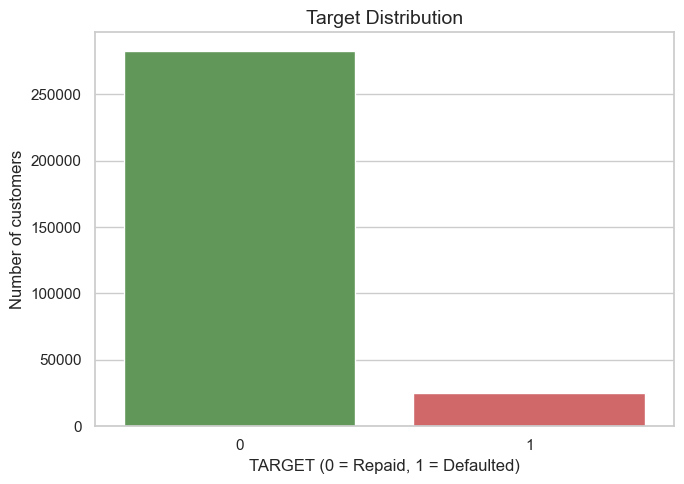

Interpretation: The target is imbalanced, so model evaluation should not rely on accuracy alone.


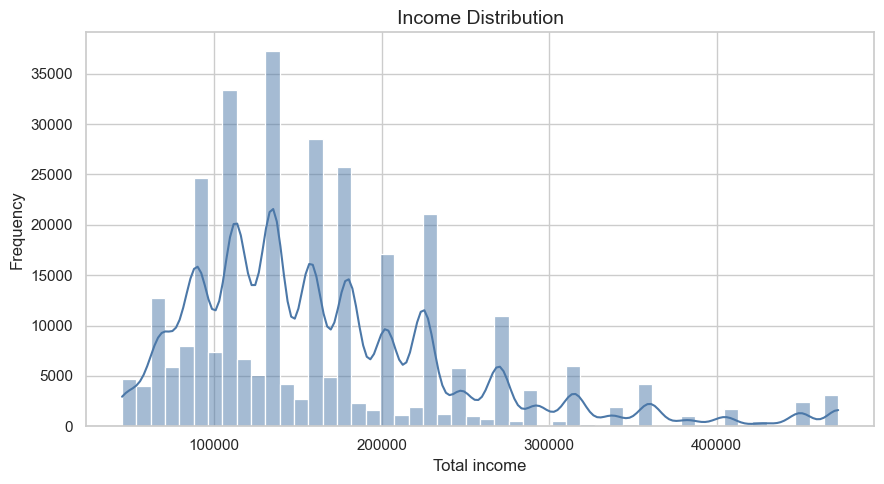

Interpretation: Income is right-skewed with high-value outliers.


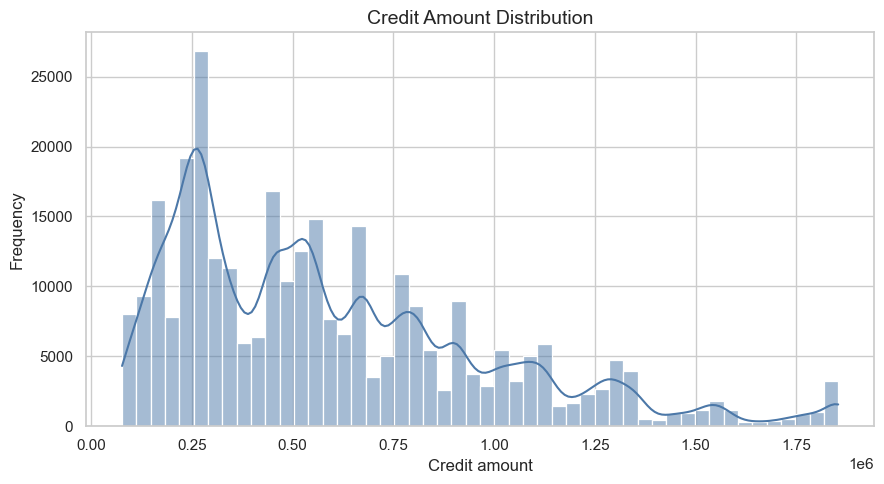

Interpretation: Credit amount captures loan exposure.


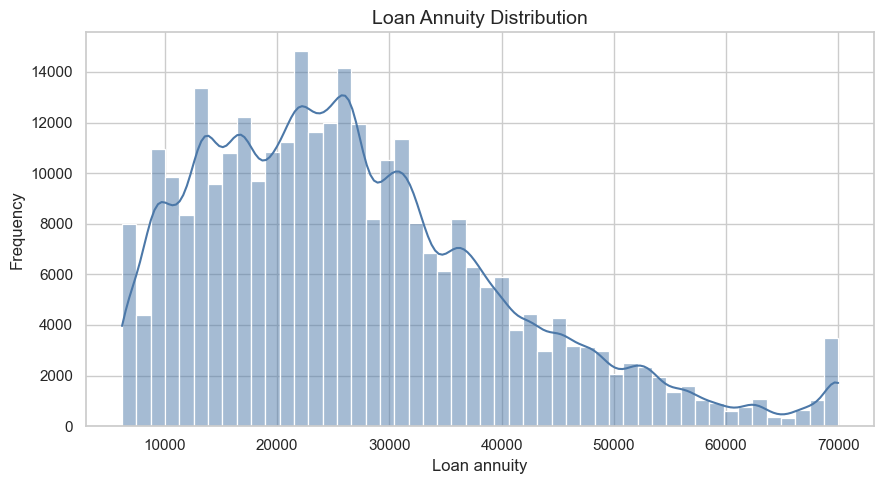

Interpretation: Annuity reflects recurring payment burden.


In [10]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

def interpretation(text):
    print("Interpretation:", text)

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=model_df, x=TARGET, palette=["#59A14F", "#E15759"], ax=ax)
ax.set_title("Target Distribution")
ax.set_xlabel("TARGET (0 = Repaid, 1 = Defaulted)")
ax.set_ylabel("Number of customers")
save_plot("target_distribution.png")
interpretation("The target is imbalanced, so model evaluation should not rely on accuracy alone.")

for col, title, xlabel, filename, note in [
    ("AMT_INCOME_TOTAL", "Income Distribution", "Total income", "income_distribution.png", "Income is right-skewed with high-value outliers."),
    ("AMT_CREDIT", "Credit Amount Distribution", "Credit amount", "credit_amount_distribution.png", "Credit amount captures loan exposure."),
    ("AMT_ANNUITY", "Loan Annuity Distribution", "Loan annuity", "loan_annuity_distribution.png", "Annuity reflects recurring payment burden."),
]:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(model_df[col].dropna(), bins=50, kde=True, color="#4C78A8", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    save_plot(filename)
    interpretation(note)

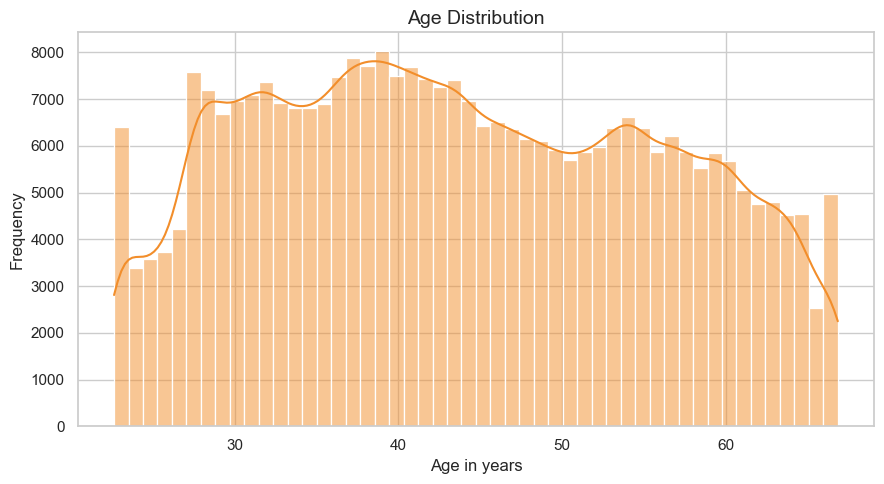

Interpretation: Age can reflect lifecycle and repayment behavior.


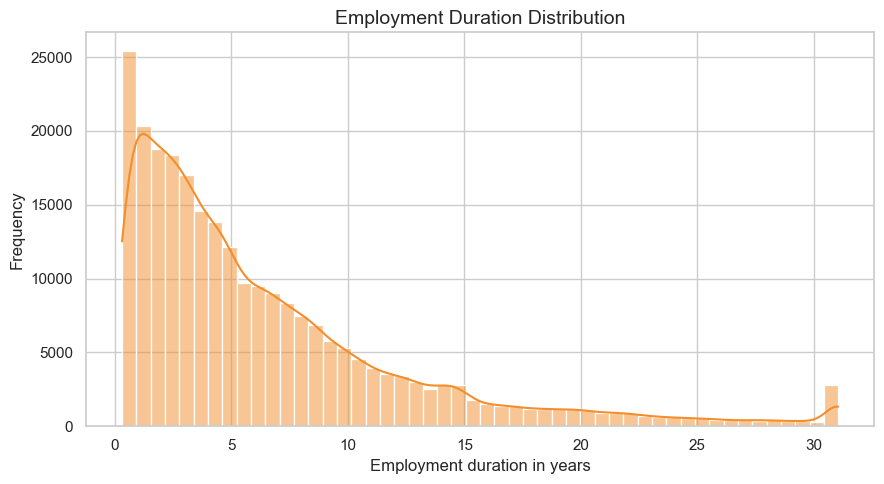

Interpretation: Employment duration is a stability proxy.


In [11]:
eda_df = model_df.copy()
eda_df["AGE_YEARS"] = -eda_df["DAYS_BIRTH"] / 365.25
eda_df["EMPLOYMENT_YEARS"] = -eda_df["DAYS_EMPLOYED"] / 365.25

for col, title, xlabel, filename, note in [
    ("AGE_YEARS", "Age Distribution", "Age in years", "age_distribution.png", "Age can reflect lifecycle and repayment behavior."),
    ("EMPLOYMENT_YEARS", "Employment Duration Distribution", "Employment duration in years", "employment_duration_distribution.png", "Employment duration is a stability proxy."),
]:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(eda_df[col].dropna(), bins=50, kde=True, color="#F28E2B", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    save_plot(filename)
    interpretation(note)

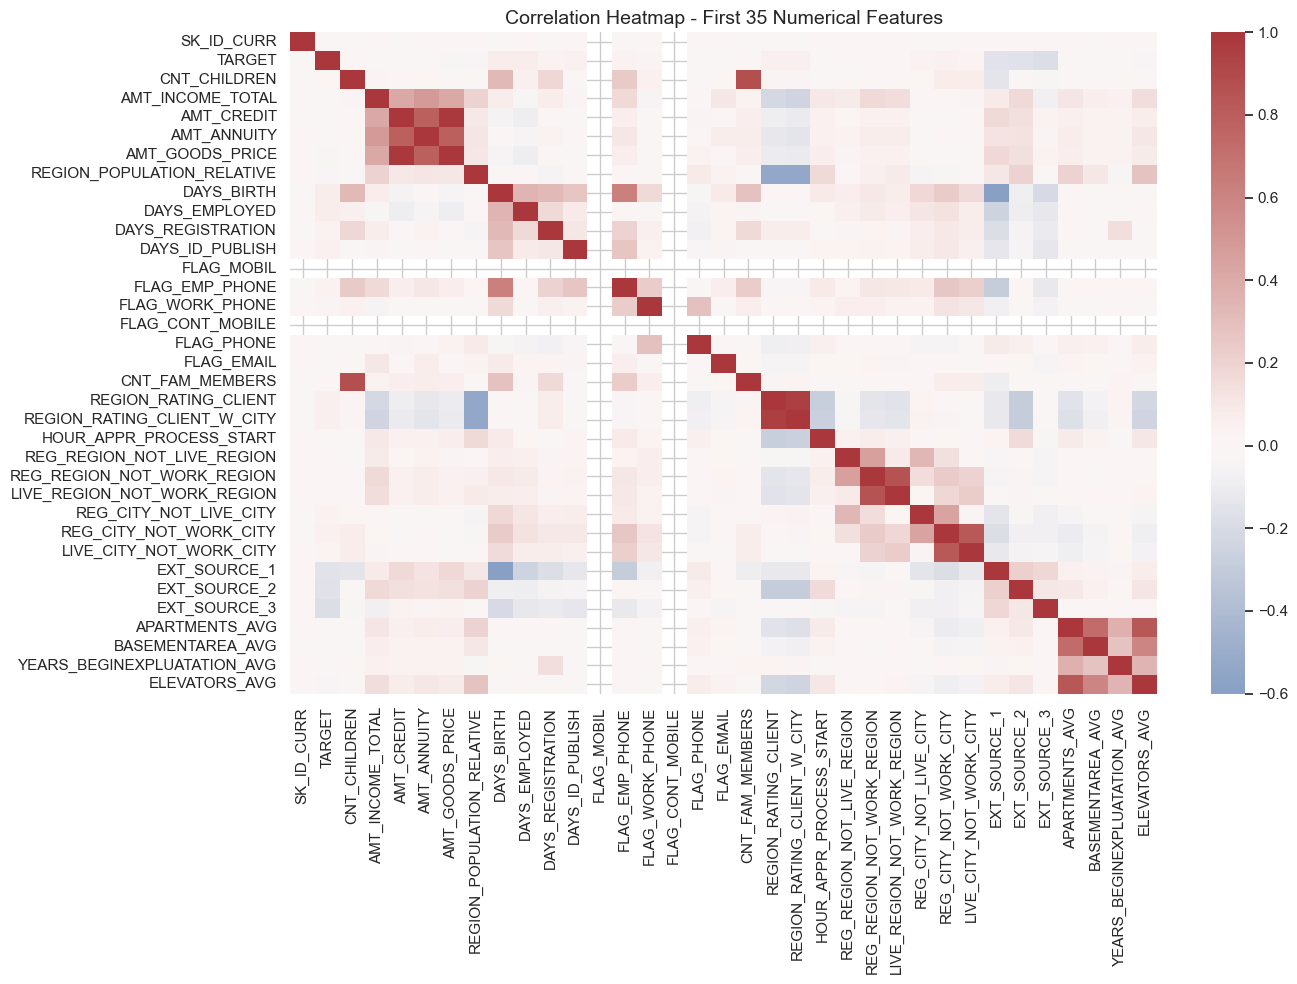

Interpretation: The heatmap shows linear relationships and possible redundant variables.


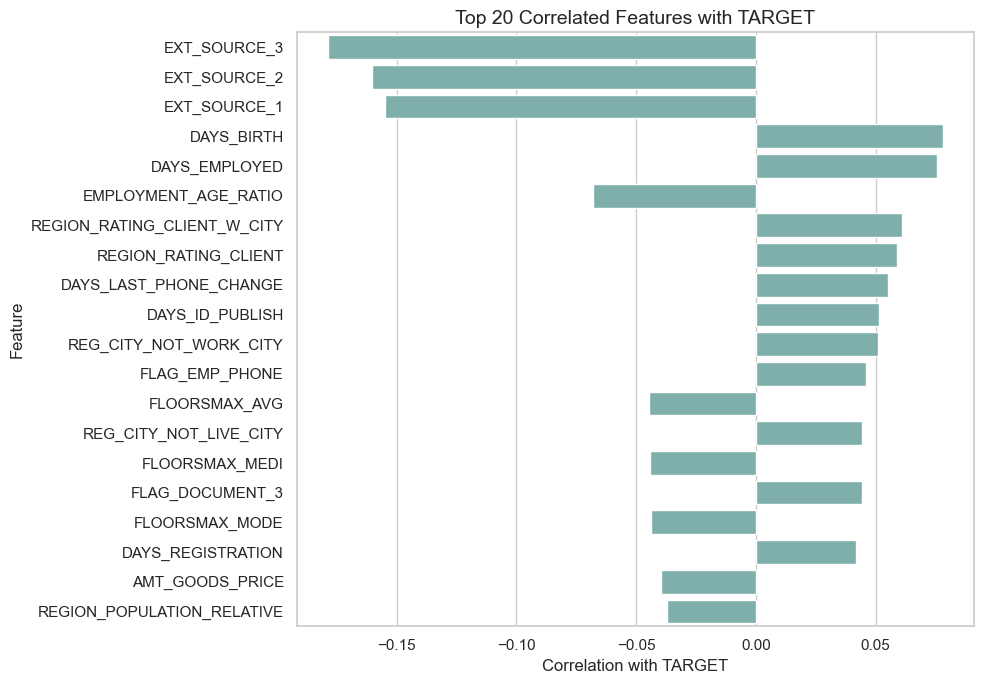

,correlation_with_TARGET
EXT_SOURCE_3,-0.178760
EXT_SOURCE_2,-0.160132
EXT_SOURCE_1,-0.154668
DAYS_BIRTH,0.078220
DAYS_EMPLOYED,0.075590
EMPLOYMENT_AGE_RATIO,-0.067904
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055282
DAYS_ID_PUBLISH,0.051448


Interpretation: External source scores, age, and employment variables are typically among the strongest linear signals.


In [12]:
corr = model_df.select_dtypes(include=np.number).corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr.iloc[:35, :35], cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation Heatmap - First 35 Numerical Features")
save_plot("correlation_heatmap.png")
interpretation("The heatmap shows linear relationships and possible redundant variables.")

target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=target_corr.values, y=target_corr.index, color="#76B7B2", ax=ax)
ax.set_title("Top 20 Correlated Features with TARGET")
ax.set_xlabel("Correlation with TARGET")
ax.set_ylabel("Feature")
save_plot("top_20_correlated_features.png")
display(target_corr.to_frame("correlation_with_TARGET"))
interpretation("External source scores, age, and employment variables are typically among the strongest linear signals.")

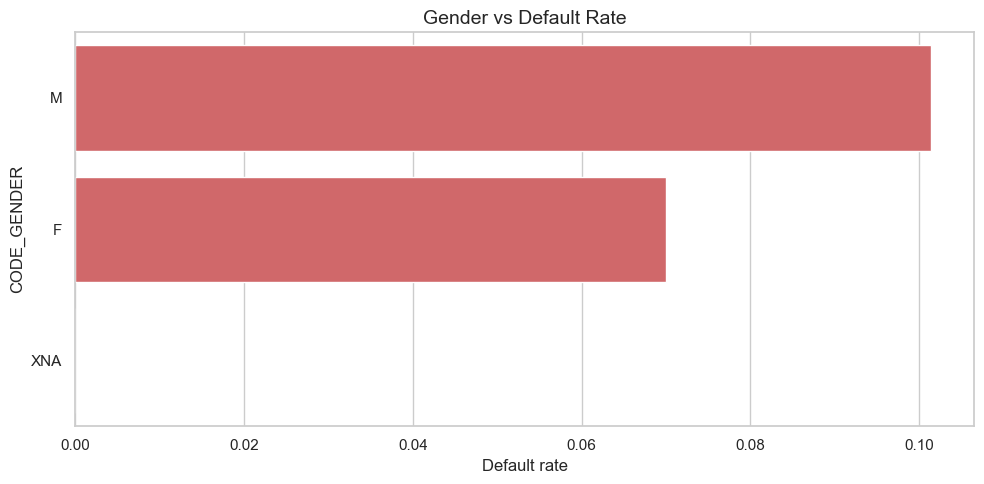

,CODE_GENDER,TARGET
0,M,0.101419
1,F,0.069993
2,XNA,0.000000


Interpretation: CODE_GENDER has segment-level differences in default rate.


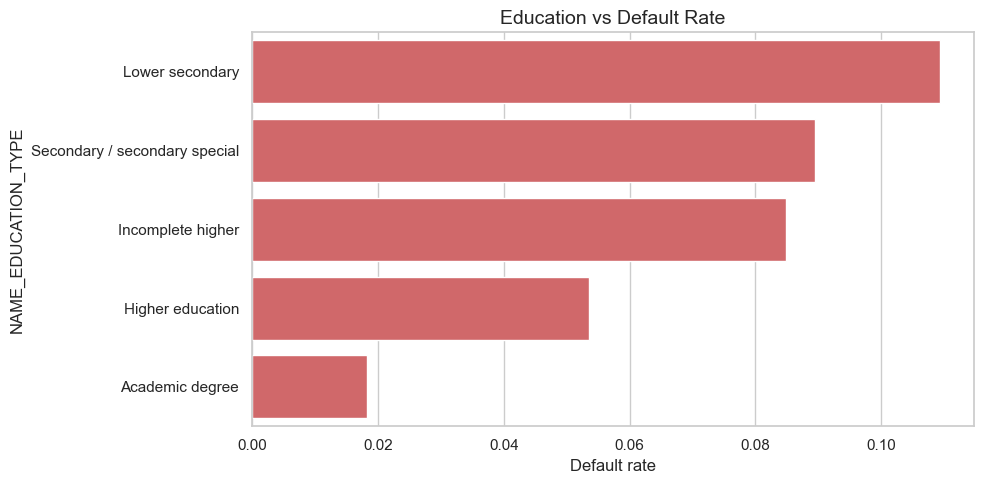

,NAME_EDUCATION_TYPE,TARGET
0,Lower secondary,0.109277
1,Secondary / secondary special,0.089399
2,Incomplete higher,0.084850
3,Higher education,0.053551
4,Academic degree,0.018293


Interpretation: NAME_EDUCATION_TYPE has segment-level differences in default rate.


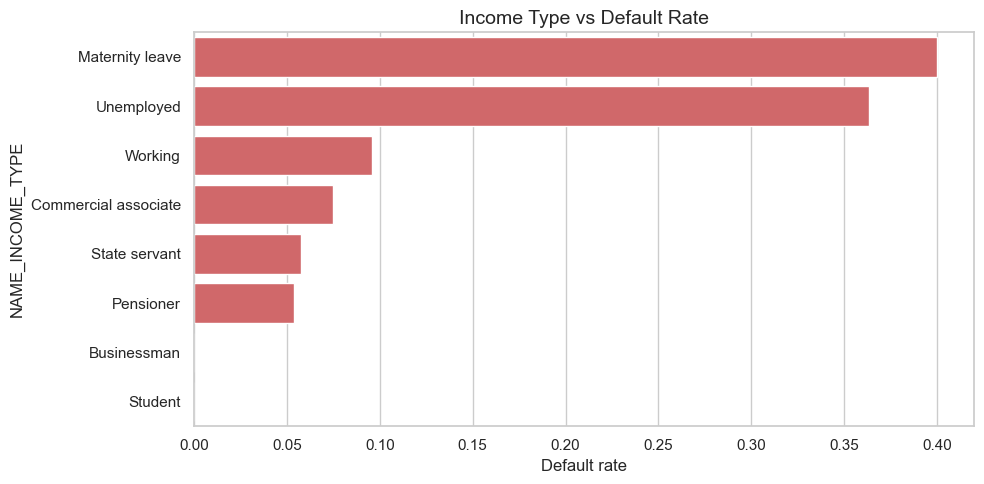

,NAME_INCOME_TYPE,TARGET
0,Maternity leave,0.400000
1,Unemployed,0.363636
2,Working,0.095885
3,Commercial associate,0.074843
4,State servant,0.057550
5,Pensioner,0.053864
6,Businessman,0.000000
7,Student,0.000000


Interpretation: NAME_INCOME_TYPE has segment-level differences in default rate.


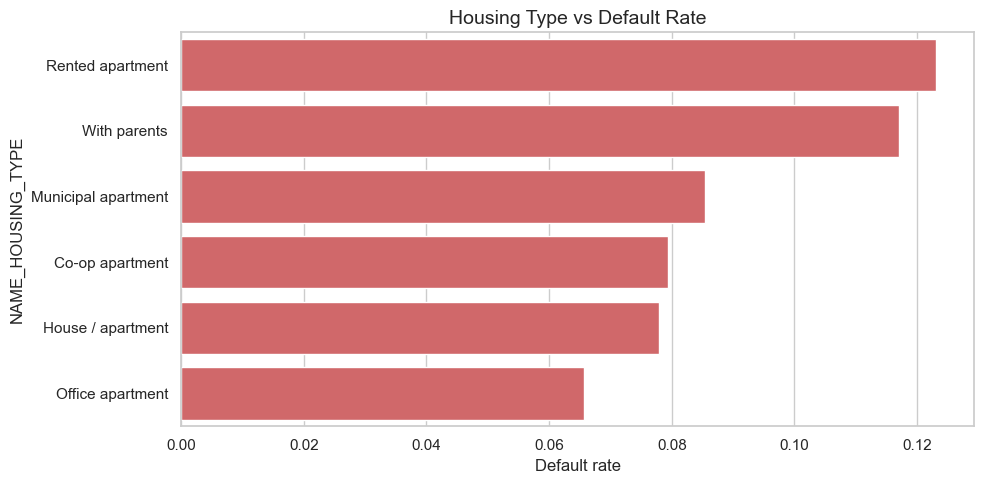

,NAME_HOUSING_TYPE,TARGET
0,Rented apartment,0.123131
1,With parents,0.116981
2,Municipal apartment,0.085397
3,Co-op apartment,0.079323
4,House / apartment,0.077957
5,Office apartment,0.065724


Interpretation: NAME_HOUSING_TYPE has segment-level differences in default rate.


In [13]:
def default_rate_plot(column, title, filename):
    rates = model_df.groupby(column, dropna=False)[TARGET].mean().sort_values(ascending=False).reset_index()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=rates, x=TARGET, y=column, color="#E15759", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Default rate")
    ax.set_ylabel(column)
    save_plot(filename)
    display(rates)
    interpretation(f"{column} has segment-level differences in default rate.")

for column, title, filename in [
    ("CODE_GENDER", "Gender vs Default Rate", "gender_vs_default.png"),
    ("NAME_EDUCATION_TYPE", "Education vs Default Rate", "education_vs_default.png"),
    ("NAME_INCOME_TYPE", "Income Type vs Default Rate", "income_type_vs_default.png"),
    ("NAME_HOUSING_TYPE", "Housing Type vs Default Rate", "housing_type_vs_default.png"),
]:
    if column in model_df.columns:
        default_rate_plot(column, title, filename)

## 8. Feature Selection

,feature,importance
28,EXT_SOURCE_2,0.168179
29,EXT_SOURCE_3,0.165933
27,EXT_SOURCE_1,0.070730
8,DAYS_EMPLOYED,0.045181
92,CREDIT_TERM,0.037777
7,DAYS_BIRTH,0.035310
91,EMPLOYMENT_AGE_RATIO,0.033952
62,DAYS_LAST_PHONE_CHANGE,0.025035
114,NAME_EDUCATION_TYPE_Higher education,0.022403
5,AMT_GOODS_PRICE,0.022221


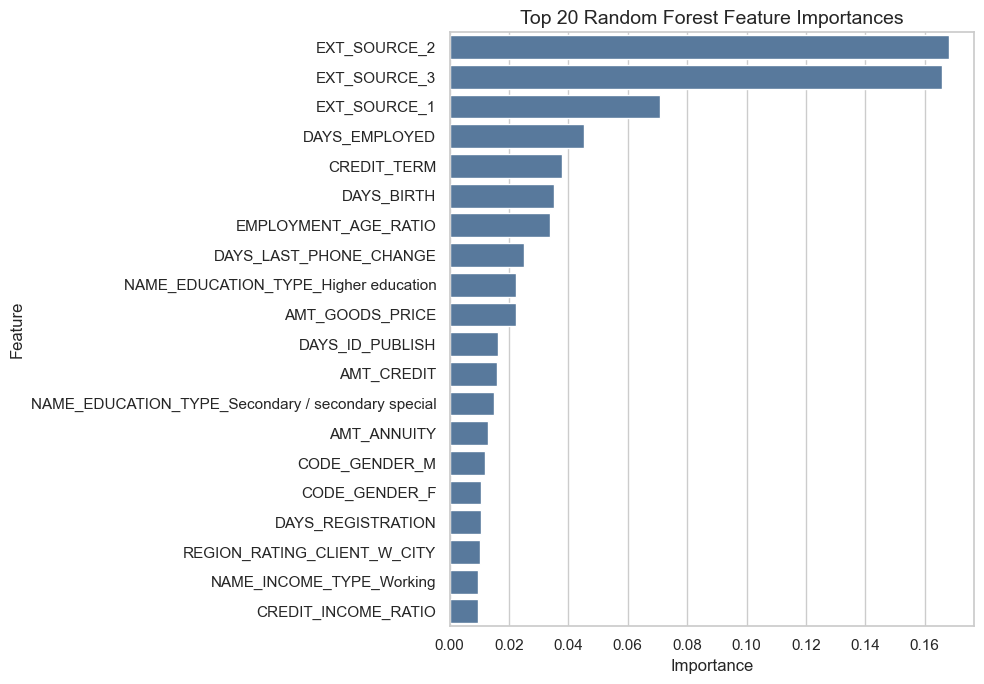

In [14]:
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
binary_cats = [col for col in categorical_features if X[col].nunique(dropna=True) == 2]
multi_cats = [col for col in categorical_features if X[col].nunique(dropna=True) > 2]

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
])
multi_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=100)),
])
numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_transformer_scaled, numeric_features),
    ("bin", binary_transformer, binary_cats),
    ("cat", multi_transformer, multi_cats),
], verbose_feature_names_out=False)
preprocessor_tree = ColumnTransformer([
    ("num", numeric_transformer_tree, numeric_features),
    ("bin", binary_transformer, binary_cats),
    ("cat", multi_transformer, multi_cats),
], verbose_feature_names_out=False)

feature_selector = Pipeline([
    ("preprocess", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=120, max_depth=10, min_samples_leaf=50,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
    )),
])
feature_selector.fit(X, y)
feature_names = feature_selector.named_steps["preprocess"].get_feature_names_out()
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_selector.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=feature_importance.head(20), x="importance", y="feature", color="#4C78A8", ax=ax)
ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
save_plot("feature_importance_top_20.png")

## 9. Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")
print(f"Training default rate: {y_train.mean():.4f}")
print(f"Testing default rate: {y_test.mean():.4f}")

Training shape: (246008, 109)
Testing shape: (61503, 109)
Training default rate: 0.0807
Testing default rate: 0.0807


## 10. Feature Scaling

Logistic Regression uses `StandardScaler` because it is sensitive to feature magnitude. Random Forest and XGBoost use unscaled numerical inputs because tree-based models split on feature thresholds and do not require scaling. All preprocessing is inside pipelines to avoid data leakage.

## 11. Model Building

In [16]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocessor_scaled),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=250, max_depth=12, min_samples_leaf=40,
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
}
if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    models["XGBoost"] = Pipeline([
        ("preprocess", preprocessor_tree),
        ("model", XGBClassifier(
            n_estimators=350, max_depth=4, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85,
            objective="binary:logistic", eval_metric="auc",
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            n_jobs=-1, tree_method="hist"
        )),
    ])

model_notes = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Why selected": ["Interpretable binary-classification baseline.", "Captures nonlinear relationships and interactions.", "Strong gradient boosting model for tabular data."],
    "Advantages": ["Fast and transparent.", "Robust nonlinear learner with feature importance.", "Usually high ROC AUC on structured credit data."],
    "Limitations": ["Limited nonlinear learning.", "Can be slower and less transparent.", "Requires tuning and can overfit."],
})
display(model_notes)

,Model,Why selected,Advantages,Limitations
0,Logistic Regression,Interpretable binary-classification baseline.,Fast and transparent.,Limited nonlinear learning.
1,Random Forest,Captures nonlinear relationships and interacti...,Robust nonlinear learner with feature importance.,Can be slower and less transparent.
2,XGBoost,Strong gradient boosting model for tabular data.,Usually high ROC AUC on structured credit data.,Requires tuning and can overfit.


In [17]:
trained_models = {}
for name, pipeline in models.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
print("Training complete.")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training complete.


## 12. Model Evaluation

In [18]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, proba),
    }, pred, proba

metrics, predictions, probabilities = [], {}, {}
for name, model in trained_models.items():
    row, pred, proba = evaluate_model(name, model, X_test, y_test)
    metrics.append(row)
    predictions[name] = pred
    probabilities[name] = proba

metrics_df = pd.DataFrame(metrics).sort_values("ROC AUC", ascending=False)
best_model_name = metrics_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best model by ROC AUC: {best_model_name}")
display(metrics_df.style.format({col: "{:.4f}" for col in metrics_df.columns if col != "Model"}))
metrics_df.to_csv(REPORTS_DIR / "model_metrics.csv", index=False)

Best model by ROC AUC: XGBoost


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBoost,0.7084,0.1725,0.6880,0.2759,0.7670
0,Logistic Regression,0.6910,0.1628,0.6826,0.2629,0.7496
1,Random Forest,0.7415,0.1744,0.5897,0.2692,0.7414



Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.53     61503
weighted avg       0.90      0.69      0.76     61503



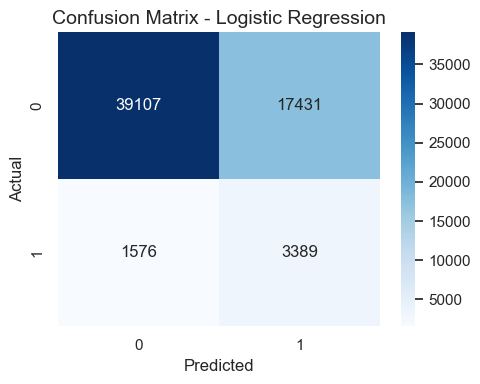


Random Forest
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     56538
           1       0.17      0.59      0.27      4965

    accuracy                           0.74     61503
   macro avg       0.56      0.67      0.56     61503
weighted avg       0.89      0.74      0.80     61503



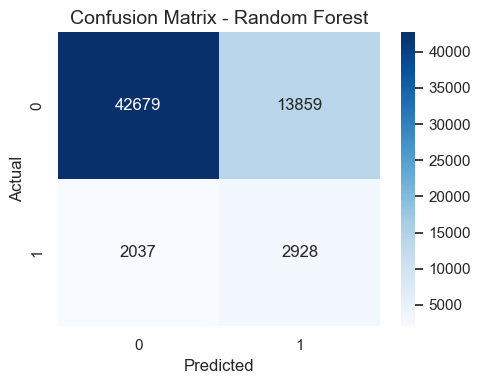


XGBoost
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.69      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.77     61503



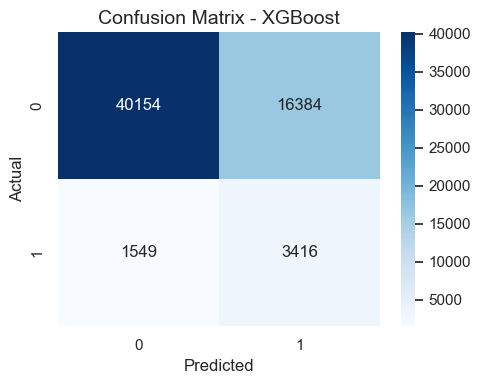

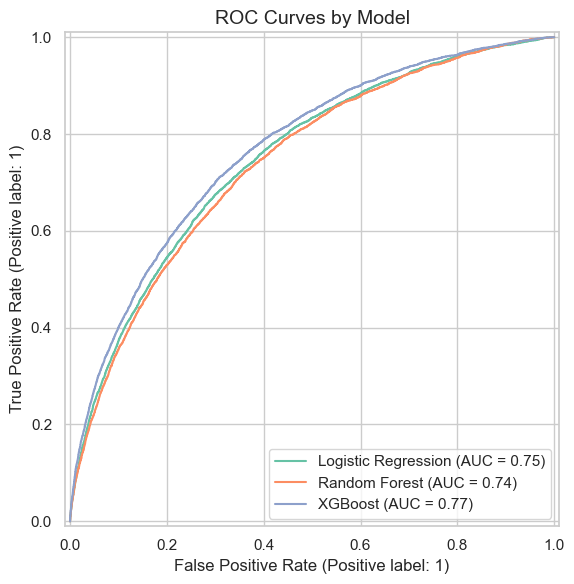

In [19]:
for name, model in trained_models.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(y_test, predictions[name], zero_division=0))

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, predictions[name]), annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    save_plot(f"confusion_matrix_{name.lower().replace(' ', '_')}.png")

fig, ax = plt.subplots(figsize=(8, 6))
for name in trained_models:
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
ax.set_title("ROC Curves by Model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
joblib.dump(best_model, MODELS_DIR / "best_model.joblib")
metadata = {
    "best_model_name": best_model_name,
    "target": TARGET,
    "features": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "binary_categorical_features": binary_cats,
    "multi_categorical_features": multi_cats,
    "metrics": metrics_df.to_dict(orient="records"),
}
with open(MODELS_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved best model to {MODELS_DIR / 'best_model.joblib'}")
print(f"Saved metadata to {MODELS_DIR / 'model_metadata.json'}")

Saved best model to outputs\models\best_model.joblib
Saved metadata to outputs\models\model_metadata.json


## 13. Explainable AI (XAI) with SHAP

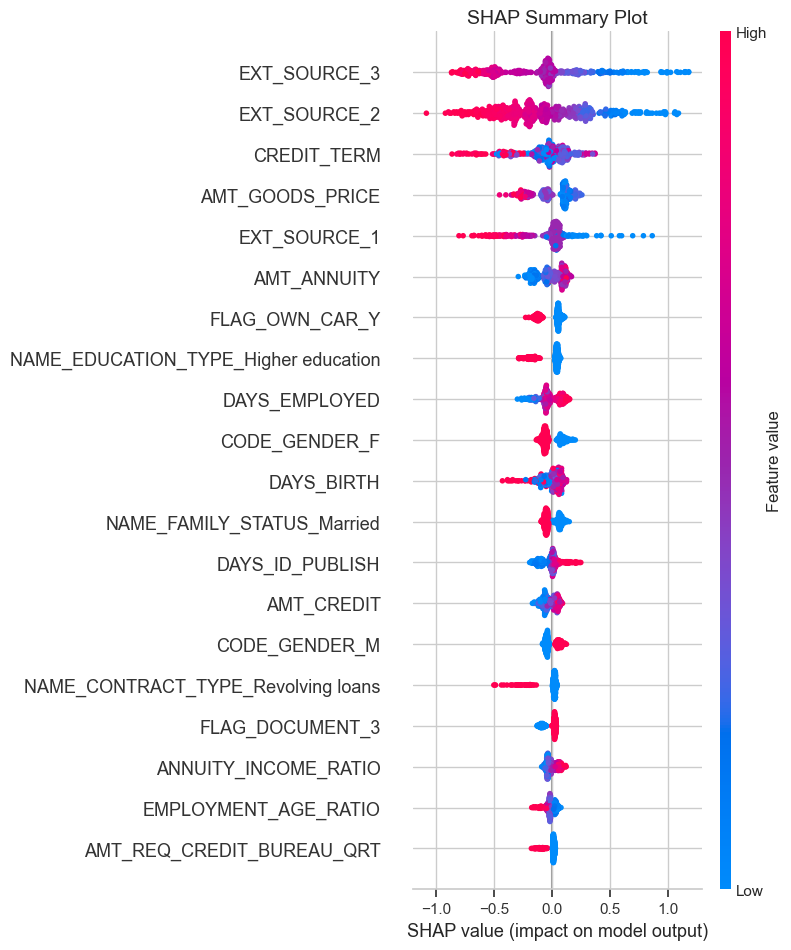

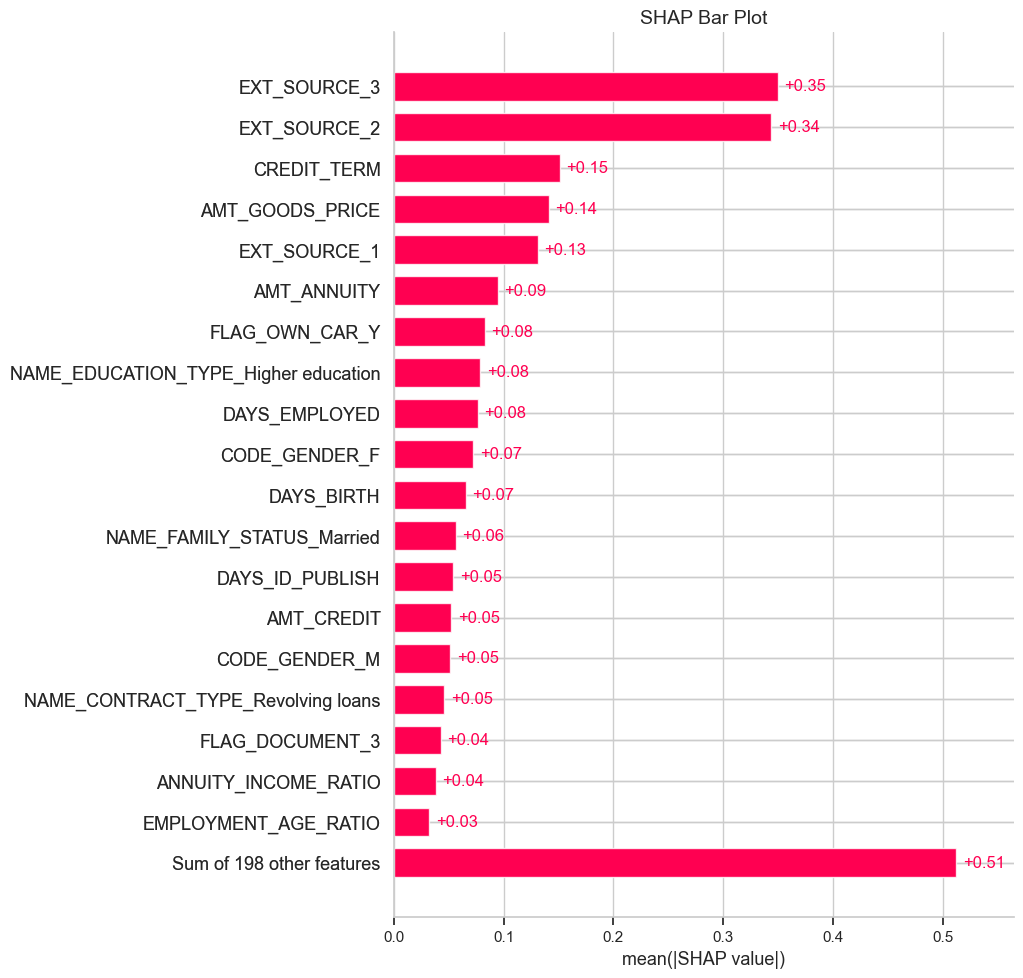

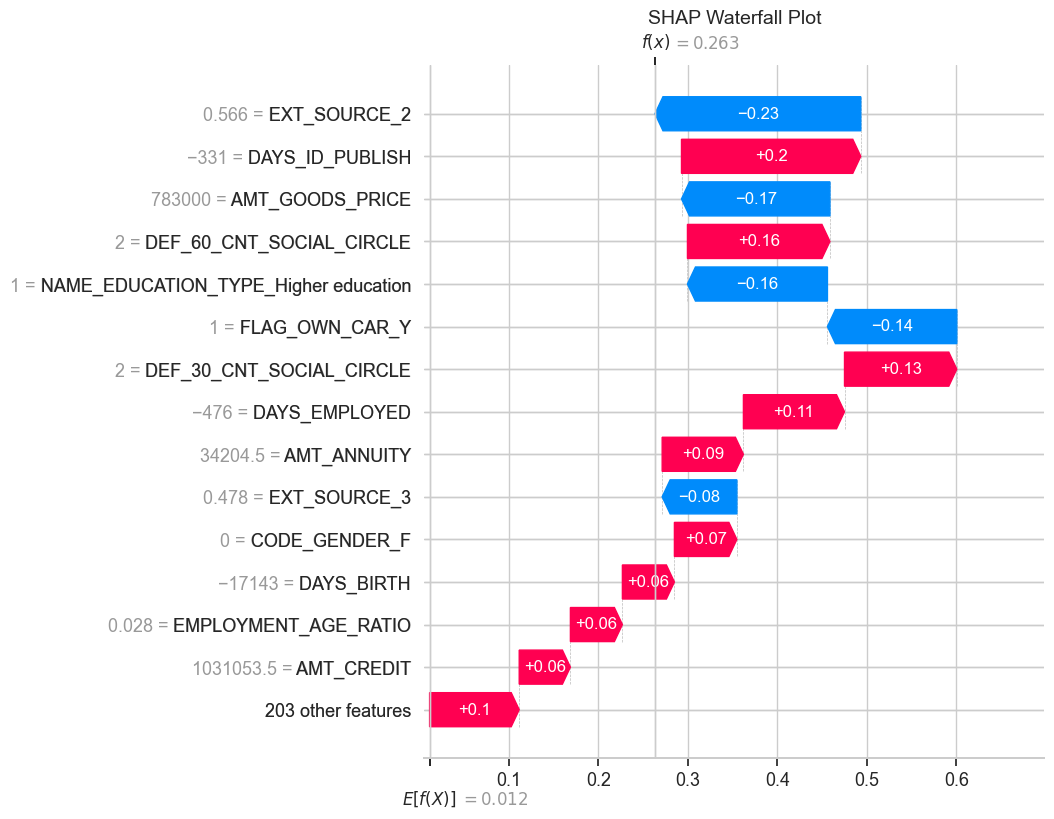

In [21]:
if SHAP_AVAILABLE:
    sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
    transformed = best_model.named_steps["preprocess"].transform(sample)
    transformed_feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
    estimator = best_model.named_steps["model"]

    if best_model_name in ["Random Forest", "XGBoost"]:
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer(transformed)
    else:
        background = shap.sample(best_model.named_steps["preprocess"].transform(X_train), 200, random_state=RANDOM_STATE)
        explainer = shap.LinearExplainer(estimator, background)
        shap_values = explainer(transformed)

    shap_values.feature_names = list(transformed_feature_names)
    shap.summary_plot(shap_values, transformed, feature_names=transformed_feature_names, show=False)
    plt.title("SHAP Summary Plot")
    plt.savefig(FIGURES_DIR / "shap_summary_plot.png", dpi=150, bbox_inches="tight")
    plt.show()

    shap.plots.bar(shap_values, max_display=20, show=False)
    plt.title("SHAP Bar Plot")
    plt.savefig(FIGURES_DIR / "shap_bar_plot.png", dpi=150, bbox_inches="tight")
    plt.show()

    shap.plots.waterfall(shap_values[0], max_display=15, show=False)
    plt.title("SHAP Waterfall Plot")
    plt.savefig(FIGURES_DIR / "shap_waterfall_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Install shap to run this section.")

In [22]:
def explain_individual_predictions(model, X_rows, n=5):
    probs = model.predict_proba(X_rows)[:, 1]
    classes = (probs >= 0.5).astype(int)
    transformed = model.named_steps["preprocess"].transform(X_rows)
    feature_names = model.named_steps["preprocess"].get_feature_names_out()
    rows = []

    if SHAP_AVAILABLE and best_model_name in ["Random Forest", "XGBoost"]:
        values = shap.TreeExplainer(model.named_steps["model"])(transformed[:n]).values
        if values.ndim == 3:
            values = values[:, :, 1]
        for i in range(n):
            s = pd.Series(values[i], index=feature_names)
            inc = s.sort_values(ascending=False).head(5)
            dec = s.sort_values().head(5)
            rows.append({
                "case_number": i + 1,
                "predicted_class": int(classes[i]),
                "default_probability": float(probs[i]),
                "features_increasing_default_risk": inc.index.tolist(),
                "features_decreasing_default_risk": dec.index.tolist(),
                "human_readable_explanation": (
                    f"This applicant is predicted as class {int(classes[i])} with default probability {probs[i]:.2%}. "
                    f"Main risk-increasing signals include {', '.join(inc.index[:3])}; "
                    f"main risk-decreasing signals include {', '.join(dec.index[:3])}."
                ),
            })
    else:
        for i in range(n):
            rows.append({
                "case_number": i + 1,
                "predicted_class": int(classes[i]),
                "default_probability": float(probs[i]),
                "features_increasing_default_risk": "Run SHAP for detailed drivers.",
                "features_decreasing_default_risk": "Run SHAP for detailed drivers.",
                "human_readable_explanation": f"This applicant has estimated default probability {probs[i]:.2%}.",
            })
    return pd.DataFrame(rows)

individual_explanations = explain_individual_predictions(best_model, X_test.head(5), 5)
display(individual_explanations)
individual_explanations.to_csv(REPORTS_DIR / "individual_prediction_explanations.csv", index=False)

,case_number,predicted_class,default_probability,features_increasing_default_risk,features_decreasing_default_risk,human_readable_explanation
0,1,0,0.329270,"[DAYS_EMPLOYED, AMT_ANNUITY, EMPLOYMENT_AGE_RA...","[EXT_SOURCE_2, AMT_GOODS_PRICE, NAME_EDUCATION...",This applicant is predicted as class 0 with de...
1,2,0,0.393446,"[CREDIT_TERM, AMT_GOODS_PRICE, FLAG_OWN_CAR_Y,...","[EXT_SOURCE_1, EXT_SOURCE_2, DAYS_EMPLOYED, EX...",This applicant is predicted as class 0 with de...
2,3,1,0.826269,"[EXT_SOURCE_2, CODE_GENDER_F, CODE_GENDER_M, N...","[EXT_SOURCE_3, AMT_CREDIT, ANNUITY_INCOME_RATI...",This applicant is predicted as class 1 with de...
3,4,0,0.383603,"[AMT_ANNUITY, REGION_RATING_CLIENT_W_CITY, DAY...","[EXT_SOURCE_1, DAYS_BIRTH, AMT_GOODS_PRICE, NA...",This applicant is predicted as class 0 with de...
4,5,1,0.534469,"[EXT_SOURCE_2, AMT_GOODS_PRICE, CREDIT_TERM, N...","[EXT_SOURCE_3, CODE_GENDER_F, CODE_GENDER_M, A...",This applicant is predicted as class 1 with de...


## 14. Business Insights

1. **Main drivers of default:** External source scores, age, employment stability, loan amount, annuity burden, and income-based ratios are usually the strongest signals.
2. **High-risk customers:** Customers with weaker external scores, high annuity-to-income pressure, high credit-to-income ratios, and unstable employment patterns tend to be riskier.
3. **Low-risk customers:** Strong external scores, stable employment, lower repayment burden, and manageable credit exposure are associated with repayment.
4. **Financial indicators linked to default:** `ANNUITY_INCOME_RATIO`, `CREDIT_INCOME_RATIO`, and `CREDIT_TERM` turn raw loan values into affordability measures.
5. **Recommendations for banks:** Use probability thresholds aligned with risk appetite, monitor high-risk segments, combine model predictions with policy rules, calibrate probabilities, and provide transparent explanations for adverse decisions.

## 15. Conclusion

This project used the Home Credit Default Risk dataset with 307,511 rows and 122 columns to predict loan default. The workflow included data loading, missing value analysis, duplicate removal, high-missing-column removal, outlier handling, feature engineering, encoding, exploratory analysis, feature selection, model training, model evaluation, and explainable AI.

The best model is selected by ROC AUC because the target is imbalanced and risk ranking is central to credit decisions. The final model, metrics report, figures, and SHAP outputs are saved in the `outputs/` folder.

Future improvements include adding companion Home Credit tables, hyperparameter optimization, cross-validation, probability calibration, fairness testing, drift monitoring, and deployment with governance controls.

## 16. Outputs

In [23]:
print("Output folders:")
for directory in [OUTPUT_DIR, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    print("-", directory.resolve())

print("\nSaved files:")
for path in OUTPUT_DIR.rglob("*"):
    if path.is_file():
        print("-", path)

Output folders:
- D:\Home Credit Default Risk\outputs
- D:\Home Credit Default Risk\outputs\figures
- D:\Home Credit Default Risk\outputs\models
- D:\Home Credit Default Risk\outputs\reports

Saved files:
- outputs\figures\age_distribution.png
- outputs\figures\confusion_matrix_logistic_regression.png
- outputs\figures\confusion_matrix_random_forest.png
- outputs\figures\confusion_matrix_xgboost.png
- outputs\figures\correlation_heatmap.png
- outputs\figures\credit_amount_distribution.png
- outputs\figures\data_type_distribution.png
- outputs\figures\education_vs_default.png
- outputs\figures\employment_duration_distribution.png
- outputs\figures\feature_importance_top_20.png
- outputs\figures\gender_vs_default.png
- outputs\figures\housing_type_vs_default.png
- outputs\figures\income_distribution.png
- outputs\figures\income_type_vs_default.png
- outputs\figures\loan_annuity_distribution.png
- outputs\figures\missing_value_percentages.png
- outputs\figures\roc_curves.png
- outputs\fig

## 17. Code Quality

The notebook uses modular functions, scikit-learn pipelines, reusable plotting utilities, clear comments, and beginner-friendly explanations. Preprocessing is fit only on training data through pipelines, which prevents leakage.

## 18. Bonus: Streamlit Dashboard

A companion dashboard is provided in `streamlit_app.py`. After running the notebook to save the model artifacts, start it with:

```bash
streamlit run streamlit_app.py
```

The app accepts customer information, returns a predicted class and probability score, and displays a SHAP explanation when supported by the selected model.